In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("hr.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Attrition"]=df["Attrition"].map({"Yes":1,"No":0})
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


In [9]:
df=df.drop(["EmployeeCount","StandardHours","Over18","EmployeeNumber"],axis=1)

In [10]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [11]:
df.shape

(1470, 31)

In [12]:
def salary_slab(income):
    if income < 5000:
        return "Low"
    elif income < 10000:
        return "Medium"
    else:
        return "High"

df["SalarySlab"] = df["MonthlyIncome"].apply(salary_slab)
df["SalarySlab"].value_counts()

,count
SalarySlab,
Low,749
Medium,440
High,281


In [13]:
df.to_csv("cleaned_hr_data.csv",index=False)

In [14]:
total_employees = df.shape[0]
attrition_count = df["Attrition"].sum()
attrition_rate = (attrition_count / total_employees) * 100

print("Total Employees:", total_employees)
print("Employees Left:", attrition_count)
print("Attrition Rate: {:.2f}%".format(attrition_rate))

Total Employees: 1470
Employees Left: 237
Attrition Rate: 16.12%


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

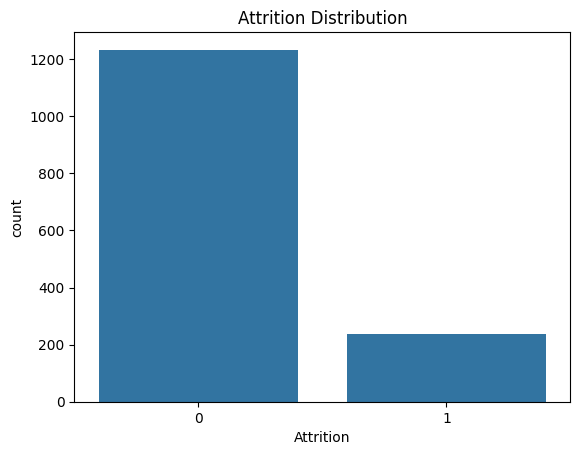

In [16]:
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution")
plt.show()

In [17]:
dept_attrition = df.groupby("Department")["Attrition"].mean().sort_values(ascending=False)
print(dept_attrition)

Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: Attrition, dtype: float64


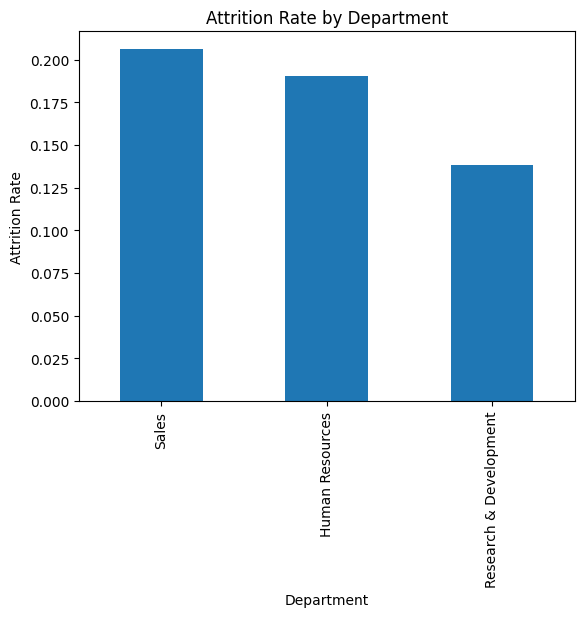

In [18]:
dept_attrition.plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate")
plt.show()

In [19]:
ot_attrition = df.groupby("OverTime")["Attrition"].mean()
print(ot_attrition)

OverTime
No     0.104364
Yes    0.305288
Name: Attrition, dtype: float64


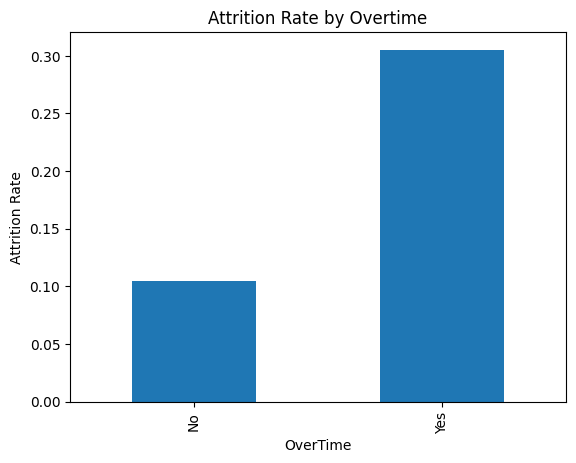

In [20]:
ot_attrition.plot(kind="bar")
plt.title("Attrition Rate by Overtime")
plt.ylabel("Attrition Rate")
plt.show()

In [21]:
salary_attrition = df.groupby("SalarySlab")["Attrition"].mean().sort_values(ascending=False)
print(salary_attrition)

SalarySlab
Low       0.217623
Medium    0.111364
High      0.088968
Name: Attrition, dtype: float64


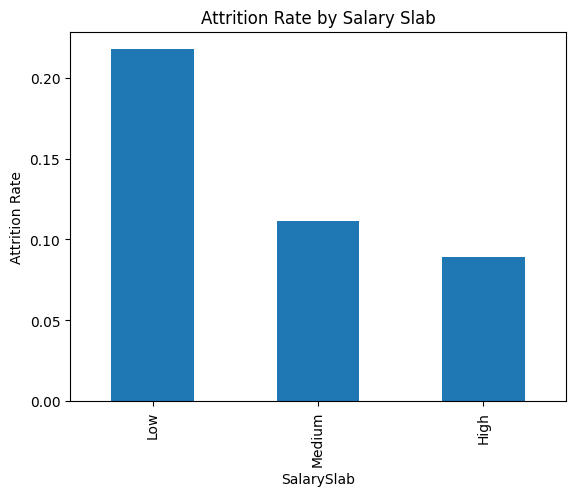

In [22]:
salary_attrition.plot(kind="bar")
plt.title("Attrition Rate by Salary Slab")
plt.ylabel("Attrition Rate")
plt.show()

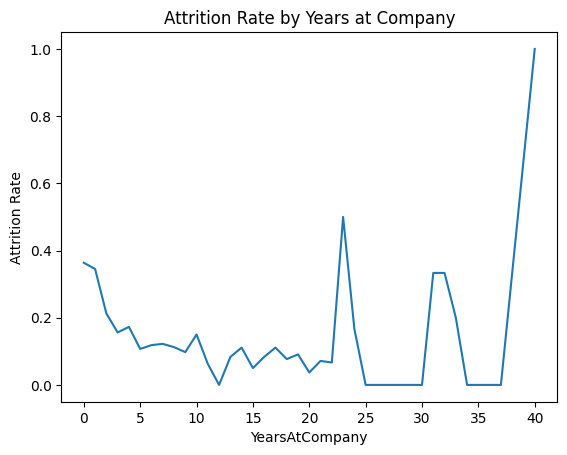

In [23]:
years_attrition = df.groupby("YearsAtCompany")["Attrition"].mean()
years_attrition.plot()
plt.title("Attrition Rate by Years at Company")
plt.ylabel("Attrition Rate")
plt.show()

In [24]:
js_attrition = df.groupby("JobSatisfaction")["Attrition"].mean()
print(js_attrition)

JobSatisfaction
1    0.228374
2    0.164286
3    0.165158
4    0.113290
Name: Attrition, dtype: float64


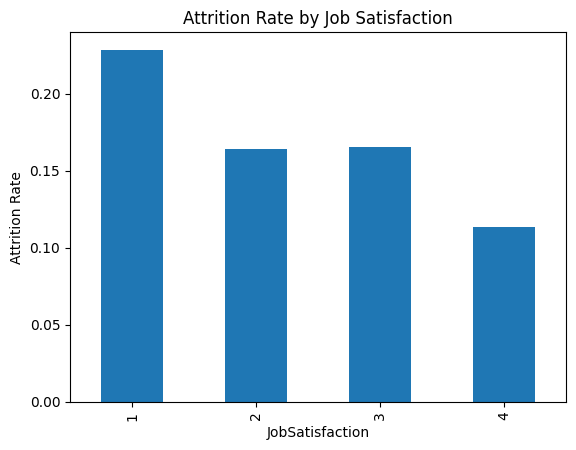

In [25]:
js_attrition.plot(kind="bar")
plt.title("Attrition Rate by Job Satisfaction")
plt.ylabel("Attrition Rate")
plt.show()

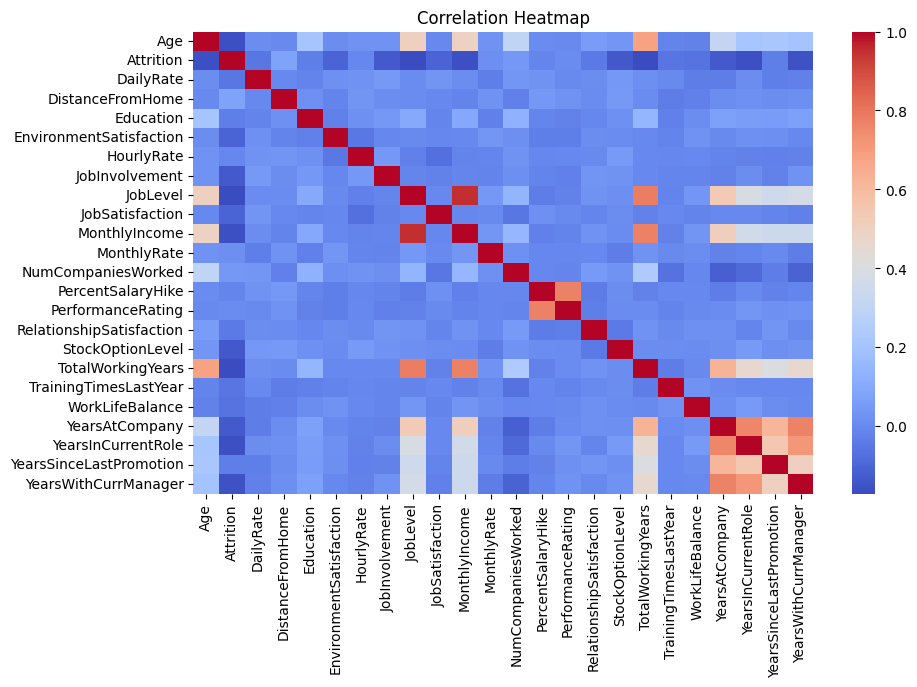

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
ot_attrition = df.groupby("OverTime")["Attrition"].mean()
print(ot_attrition)

OverTime
No     0.104364
Yes    0.305288
Name: Attrition, dtype: float64


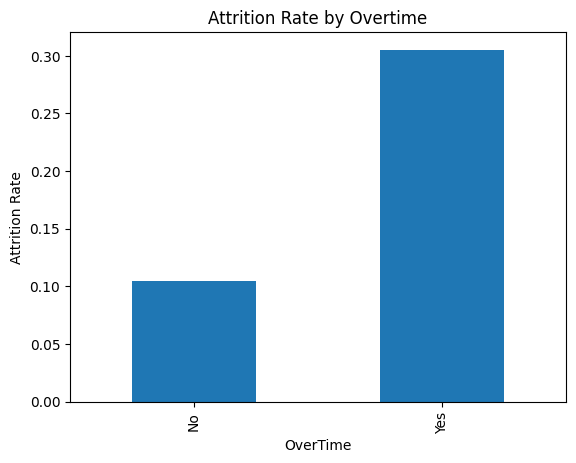

In [28]:
ot_attrition.plot(kind="bar")
plt.title("Attrition Rate by Overtime")
plt.ylabel("Attrition Rate")
plt.show()

In [29]:
salary_attrition = df.groupby("SalarySlab")["Attrition"].mean().sort_values(ascending=False)
print(salary_attrition)

SalarySlab
Low       0.217623
Medium    0.111364
High      0.088968
Name: Attrition, dtype: float64


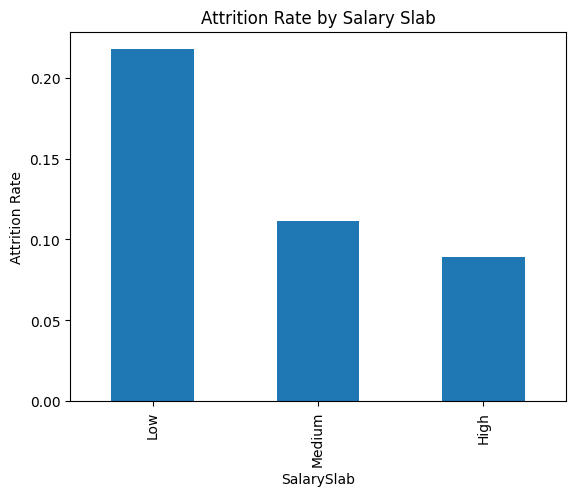

In [30]:
salary_attrition.plot(kind="bar")
plt.title("Attrition Rate by Salary Slab")
plt.ylabel("Attrition Rate")
plt.show()

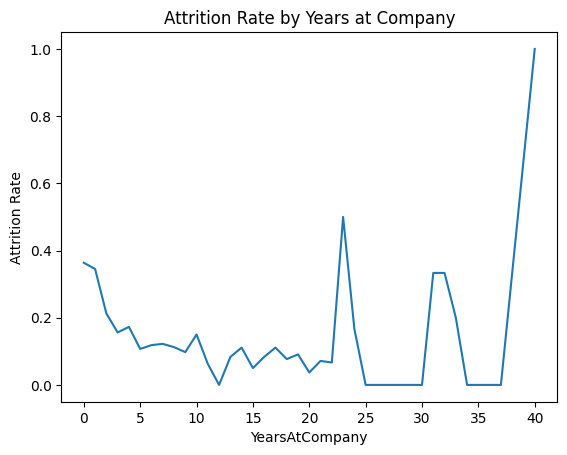

In [31]:
years_attrition = df.groupby("YearsAtCompany")["Attrition"].mean()
years_attrition.plot()
plt.title("Attrition Rate by Years at Company")
plt.ylabel("Attrition Rate")
plt.show()

In [32]:
js_attrition = df.groupby("JobSatisfaction")["Attrition"].mean()
print(js_attrition)

JobSatisfaction
1    0.228374
2    0.164286
3    0.165158
4    0.113290
Name: Attrition, dtype: float64


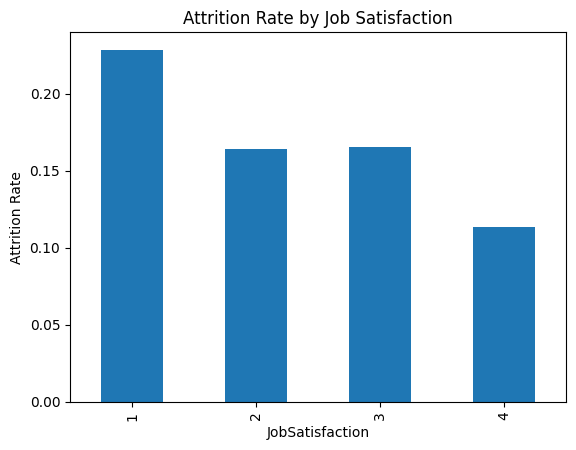

In [33]:
js_attrition.plot(kind="bar")
plt.title("Attrition Rate by Job Satisfaction")
plt.ylabel("Attrition Rate")
plt.show()

In [34]:
wlb_attrition = df.groupby("WorkLifeBalance")["Attrition"].mean()
print(wlb_attrition)

WorkLifeBalance
1    0.312500
2    0.168605
3    0.142217
4    0.176471
Name: Attrition, dtype: float64


In [35]:
df.to_csv("final_hr_data.csv",index=False)

In [36]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


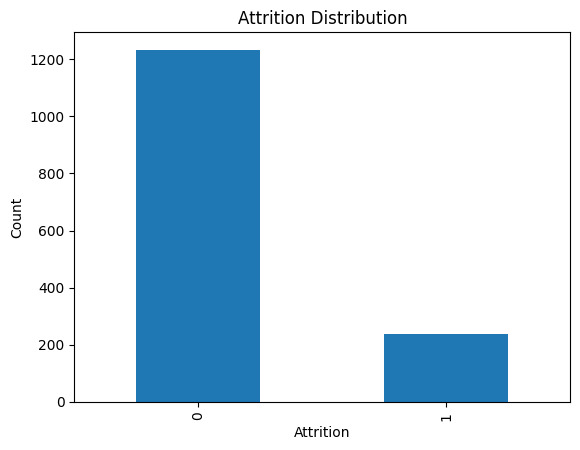

In [37]:
import matplotlib.pyplot as plt

df['Attrition'].value_counts().plot(kind='bar')
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

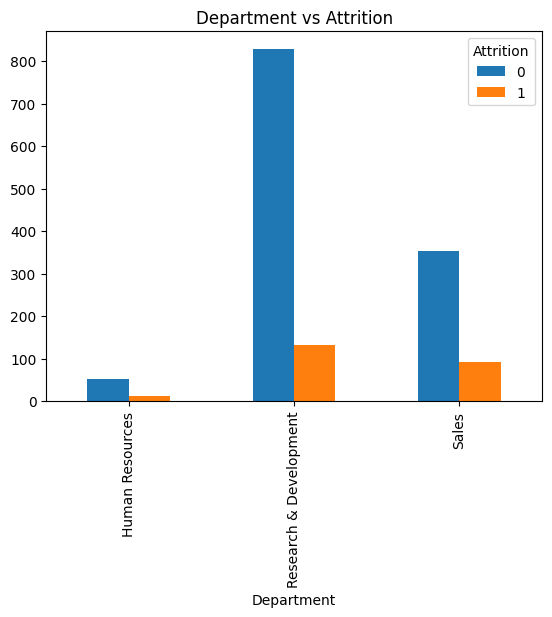

In [38]:
import pandas as pd

dept_attr = pd.crosstab(df['Department'], df['Attrition'])
dept_attr.plot(kind='bar')
plt.title("Department vs Attrition")
plt.show()

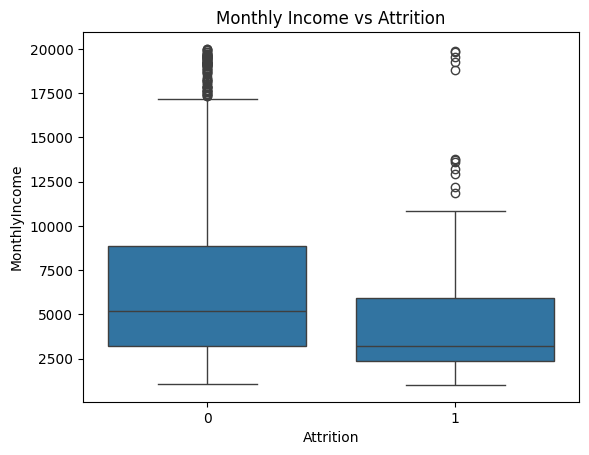

In [39]:
import seaborn as sns

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

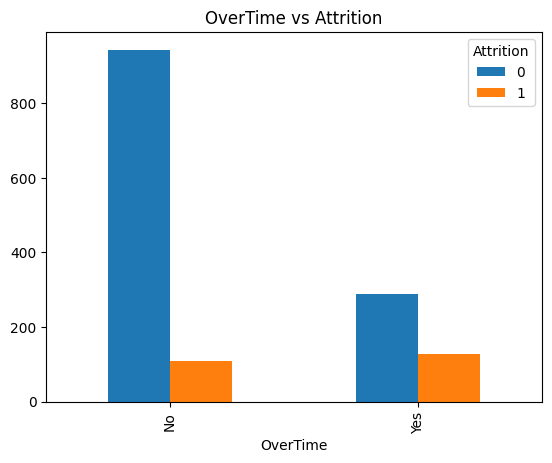

In [40]:
pd.crosstab(df['OverTime'], df['Attrition']).plot(kind='bar')
plt.title("OverTime vs Attrition")
plt.show()

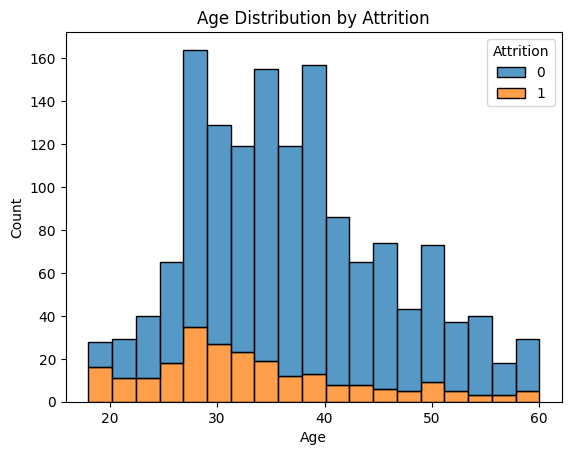

In [41]:
sns.histplot(data=df, x='Age', hue='Attrition', multiple='stack')
plt.title("Age Distribution by Attrition")
plt.show()

In [42]:
X=df.drop("Attrition",axis=1)
y=df["Attrition"]

In [43]:
X=pd.get_dummies(X,drop_first=True)

In [44]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,SalarySlab_Low,SalarySlab_Medium
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,True,False,False,True,True,False,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,True,False,False,True,False,False,False,True
2,37,1373,2,2,4,92,2,1,3,2090,...,False,False,False,False,False,False,True,True,True,False
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,True,False,False,True,False,True,True,False
4,27,591,2,1,1,40,3,1,2,3468,...,False,False,False,False,False,True,False,False,True,False


In [67]:
df["OverTime"] = df["OverTime"].map({"Yes":1,"No":0})

In [69]:
features = ["Age","MonthlyIncome","YearsAtCompany","JobSatisfaction","OverTime"]

X = df[features]
y = df["Attrition"]

In [80]:
X.isnull().sum()

,0
Age,0
MonthlyIncome,0
YearsAtCompany,0
JobSatisfaction,0
OverTime,0


In [81]:
X=X.fillna(0)

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [83]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [84]:
import pickle

with open("attrition_model.pkl","wb") as f:
    pickle.dump(model,f)

In [85]:
y_pred=model.predict(X_test)

In [86]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8673469387755102


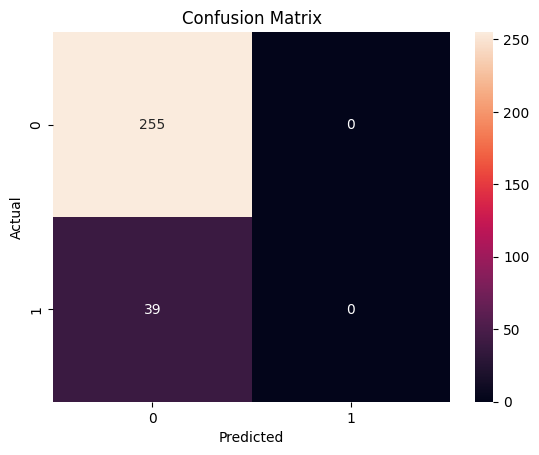

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

📊 Key Insights from Analysis

1️⃣ Overall Attrition Rate
The company has an attrition rate of 16.12%, meaning approximately 1 in 6 employees leave.

2️⃣ Salary Impact
Employees in the low salary slab have an attrition rate of 21.7%, which is significantly higher than medium and high salary employees.

3️⃣ Work-Life Balance
Employees with poor work-life balance (Level 1) show extremely high attrition (~31%).

4️⃣ Job Satisfaction
Employees with low job satisfaction show nearly double the attrition compared to highly satisfied employees.

5️⃣ Overtime
Employees working overtime have significantly higher attrition rates.

6️⃣ Early Career Employees
Higher attrition observed in employees with fewer years at company.

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [89]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [90]:
y_pred_rf=rf_model.predict(X_test)

In [91]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8435374149659864


In [92]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       255
           1       0.27      0.10      0.15        39

    accuracy                           0.84       294
   macro avg       0.57      0.53      0.53       294
weighted avg       0.79      0.84      0.81       294



In [93]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.5747109100050276


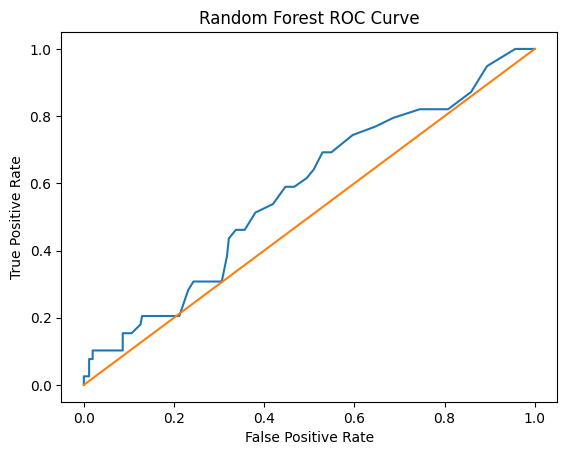

In [94]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.show()

In [95]:
import pandas as pd

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

print(top_features)

MonthlyIncome      0.450746
Age                0.268618
YearsAtCompany     0.194675
JobSatisfaction    0.085960
OverTime           0.000000
dtype: float64


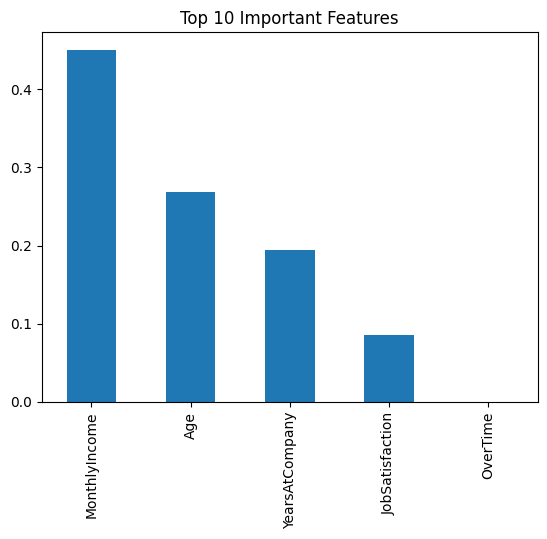

In [96]:
top_features.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

**Model Comparison**

Logistic Regression Accuracy: XX%

Random Forest Accuracy: XX%

Random Forest ROC-AUC: XX

Random Forest performed better due to its ability to capture non-linear relationships between employee attributes and attrition risk.

Feature importance analysis revealed that Overtime, Monthly Income, and Years at Company are key drivers of employee turnover.

In [97]:
import pickle

with open("attrition_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

In [98]:
%%writefile app.py
print("HR Attrition Prediction App")

Overwriting app.py


In [99]:
!pip install streamlit

In [100]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd

model = pickle.load(open("attrition_model.pkl","rb"))

st.title("HR Employee Attrition Prediction")

age = st.number_input("Age",18,60)
income = st.number_input("Monthly Income")
years = st.number_input("Years At Company")
satisfaction = st.slider("Job Satisfaction",1,4)
overtime = st.selectbox("OverTime",["Yes","No"])

overtime_value = 1 if overtime=="Yes" else 0

data = pd.DataFrame({
    "Age":[age],
    "MonthlyIncome":[income],
    "YearsAtCompany":[years],
    "JobSatisfaction":[satisfaction],
    "OverTime":[overtime_value]
})

if st.button("Predict Attrition"):
    prediction=model.predict(data)

    if prediction[0]==1:
        st.error("High Risk of Attrition")
    else:
        st.success("Low Risk of Attrition")

Overwriting app.py


In [101]:
!streamlit run app.py &>/content/logs.txt &

In [102]:
!wget -q -O - https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb > cloudflared.deb
!dpkg -i cloudflared.deb

(Reading database ... 117544 files and directories currently installed.)
Preparing to unpack cloudflared.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


In [103]:
!cloudflared tunnel --url http://localhost:8501

2026-03-11T00:26:04Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-11T00:26:04Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-11T00:26:14Z INF +--------------------------------------------------------------------------------------------+
2026-03-11T00:26:14Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-11T00:26:14Z INF |  https://aaa-started-spirits-printable.trycloudflare.c